    time [days]             flux       
-------------------- ------------------
                -0.3 0.9718556446853187
 -0.2993993993993994  0.974430548606305
 -0.2987987987987988 0.9696244442016453
 -0.2981981981981982 0.9672472927361904
 -0.2975975975975976 0.9739989623419928
  -0.296996996996997 0.9689265223770298
-0.29639639639639637 0.9678268042192515
 -0.2957957957957958 0.9676453996308826
-0.29519519519519516 0.9703558446606856
 -0.2945945945945946 0.9738800653806102
                 ...                ...
  0.2945945945945945 0.9914653112446374
 0.29519519519519516 0.9978371225844164
  0.2957957957957958  1.000796759382211
  0.2963963963963964 0.9968976911446861
 0.29699699699699694 1.0017105738372651
  0.2975975975975976 1.0025198411286196
  0.2981981981981982 0.9930781407930032
 0.29879879879879884 0.9969834224859118
 0.29939939939939936 0.9998456765152839
                 0.3 0.9997001308741668
Length = 1000 rows


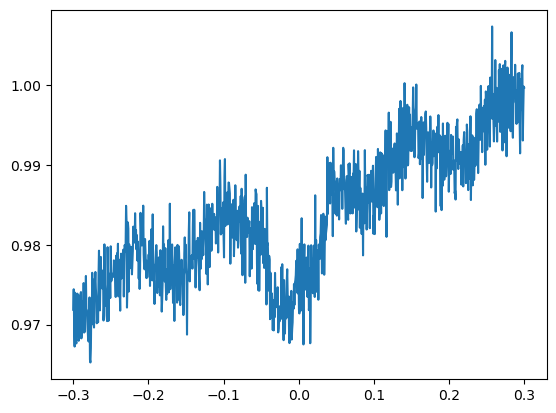

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from scipy.optimize import curve_fit
star_table = Table.read("Planet_Lightcurve.fits")
print(star_table)
xdata = star_table[ "time [days]"]
ydata = star_table["flux"]
plt.plot(xdata,ydata)

(array([ 3.92854239e-02,  2.72487509e-03,  5.05274476e+01, -2.13131585e-01,
        9.83731324e-01]), array([[ 6.86871721e-07, -2.36047726e-08, -4.29308288e-05,
        -1.93294236e-06,  4.42776524e-10],
       [-2.36047726e-08,  3.97319260e-08,  3.79704966e-06,
        -1.10424506e-07,  2.53226635e-10],
       [-4.29308288e-05,  3.79704966e-06,  1.96569064e-01,
         5.74714021e-04, -2.02736870e-06],
       [-1.93294236e-06, -1.10424506e-07,  5.74714021e-04,
         5.54020370e-03, -5.02198456e-07],
       [ 4.42776524e-10,  2.53226635e-10, -2.02736870e-06,
        -5.02198456e-07,  2.00206296e-08]]))


Text(0, 0.5, 'flux')

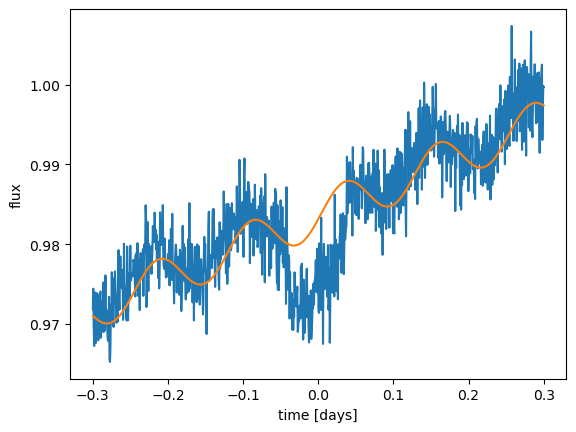

In [3]:
def lightcurve_model(xdata, a, b, c, d, e):
    return a*xdata+(b*np.sin(c*xdata+d)+e)
modelcurve=curve_fit(lightcurve_model, xdata, ydata, p0=[0.042, 0.004, 51, 0.15, 0.985]) #using modelcurve to estimate the abcde values
print(modelcurve)#finding abcde and inputting them into the lightcurve model
modelcurve_estimate=lightcurve_model(xdata,3.92854239e-02,2.72487509e-03,5.05274476e+01,-2.13131585e-01,9.83731324e-01)
plt.plot(xdata,ydata) #original plot
plt.plot(xdata,modelcurve_estimate) #estimated plot
plt.xlabel("time [days]")
plt.ylabel("flux")


(array([ 3.92854239e-02,  2.72487509e-03,  5.05274476e+01, -2.13131585e-01,
        9.83731324e-01]), array([[ 6.86871721e-07, -2.36047726e-08, -4.29308288e-05,
        -1.93294236e-06,  4.42776524e-10],
       [-2.36047726e-08,  3.97319260e-08,  3.79704966e-06,
        -1.10424506e-07,  2.53226635e-10],
       [-4.29308288e-05,  3.79704966e-06,  1.96569064e-01,
         5.74714021e-04, -2.02736870e-06],
       [-1.93294236e-06, -1.10424506e-07,  5.74714021e-04,
         5.54020370e-03, -5.02198456e-07],
       [ 4.42776524e-10,  2.53226635e-10, -2.02736870e-06,
        -5.02198456e-07,  2.00206296e-08]]))


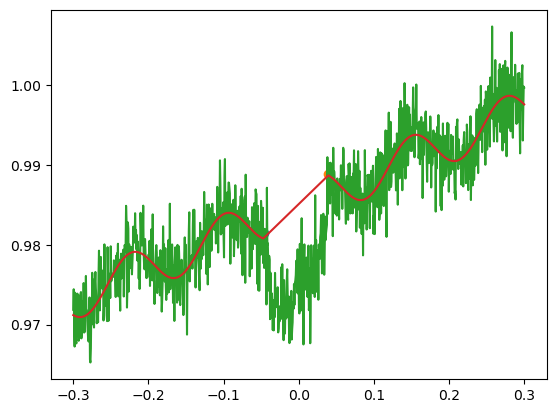

In [6]:
'''
I want the model curve to exclude the days from ~(-0.08, 0.06)
so that the curve won't be disrupted by the transit dip
'''
xdata = star_table[ "time [days]"]
ydata = star_table["flux"]
plt.plot(xdata[422],ydata[422],'o')#esxtimating the elements of the array that correspond to the beginning of the transit
plt.plot(xdata[565],ydata[565],'o')#estimating the elements of the array that correspond to the end of the transit
xdata_adjusted = np.concatenate((xdata[:422], xdata[565:]))
ydata_adjusted = np.concatenate((ydata[:422], ydata[565:]))
def lightcurve_model_adjusted(xdata_adjusted, a, b, c, d, e):
    return a*xdata_adjusted+(b*np.sin(c*xdata_adjusted+d)+e)
modelcurve_adjusted=curve_fit(lightcurve_model, xdata_adjusted, ydata_adjusted, p0=[
    0.042, 0.004, 51, 0.15, 0.985]) #using modelcurve to estimate the abcde values
print(modelcurve)#finding abcde and inputting them into the lightcurve model
modelcurve_estimate_adjusted=lightcurve_model_adjusted(
    xdata_adjusted, 3.92751577e-02, 2.76113467e-03, 5.04732493e+01, 2.70277219e-01, 9.85020568e-01)
plt.plot(xdata,ydata)
plt.plot(xdata_adjusted,modelcurve_estimate_adjusted)

(array([3.92751578e-02, 2.76113494e-03, 5.04732491e+01, 2.70277551e-01,
       9.85020568e-01]), array([[ 3.03938276e-07, -1.04155714e-08, -1.91909070e-05,
         1.10627788e-06, -3.23847376e-10],
       [-1.04155714e-08,  2.10922097e-08,  1.80352625e-06,
         4.92610542e-08, -9.36052860e-11],
       [-1.91909070e-05,  1.80352625e-06,  8.45827810e-02,
        -3.27771593e-04,  1.14613949e-06],
       [ 1.10627788e-06,  4.92610542e-08, -3.27771593e-04,
         2.69337718e-03,  1.78020394e-07],
       [-3.23847376e-10, -9.36052860e-11,  1.14613949e-06,
         1.78020394e-07,  1.03244262e-08]]))


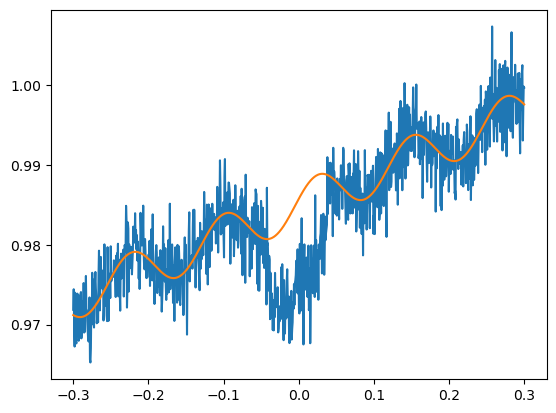

In [22]:
# define model
def lightcurve_model(xdata, a, b, c, d, e):
    return a*xdata + b*np.sin(c*xdata+d)+e

# exclude transit region from fitting
mask = (np.arange(len(xdata)) < 422) | (np.arange(len(xdata)) >= 565)

# perform fit ONLY on non-transit points
fitted_curve = curve_fit(lightcurve_model,xdata[mask],ydata[mask],p0=[0.042, 0.004, 51, 0.15, 0.985])
print(fitted_curve)
# generate smooth fitted curve over ENTIRE x range
yfit = lightcurve_model(xdata, 3.92751578e-02,2.76113494e-03,5.04732491e+01, 2.70277551e-01,9.85020568e-01)

# plot original data
plt.plot(xdata, ydata)

# plot fitted sine curve THROUGH the transit
plt.plot(xdata,yfit)

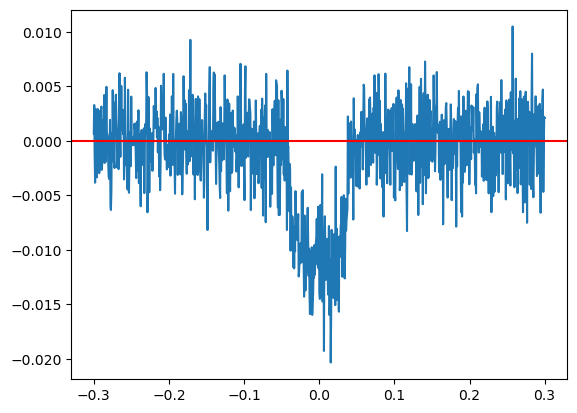

In [33]:
plt.plot(xdata, ydata- yfit)
plt.axhline(y=0, c = "red")